# Notebook 17: Compositional Null Validation

## Purpose
Validate whether compositional calculation accurately predicts pathway counts in held-out permutations.

**Critical Question**: Can we use E[path] = P(edge1) × P(edge2) to approximate pathway nulls?

## Method
1. Compute edge probabilities from permutations 1-20 (training set)
2. Predict pathway counts using compositional calculation (matrix multiplication = DP)
3. Compare to ACTUAL pathway counts in permutations 21-30 (validation set)
4. Test multiple metapaths (2-hop and 3-hop)

## Decision Criteria
- **r > 0.95**: ✓ Compositional calculation works! → Proceed to notebook 18
- **0.85 < r < 0.95**: → Compositional has bias, consider corrections
- **r < 0.85**: ✗ Compositional fails → Must use direct empirical (expensive)

## Inputs
- data/hetionet-v1.0/hetmat/edges/*.sparse.npz (permutations 1-30)
- notebooks/03_edge_frequency_by_degree.ipynb output

## Outputs
- results/compositional_validation/accuracy_by_metapath.csv
- results/compositional_validation/validation_summary.json
- results/compositional_validation/plots/*.png

## Dependencies
- Notebook 03 must be run first
- Permutations 1-30 must be available

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error
import json
import warnings
warnings.filterwarnings('ignore')

repo_dir = Path.cwd().parent
data_dir = repo_dir / 'data'
results_dir = repo_dir / 'results' / 'compositional_validation'
results_dir.mkdir(parents=True, exist_ok=True)
(results_dir / 'plots').mkdir(parents=True, exist_ok=True)

print(f"Repository: {repo_dir}")
print(f"Results will be saved to: {results_dir}")

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

Repository: /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability
Results will be saved to: /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability/results/compositional_validation


## Configuration

In [2]:
# Papermill parameters
train_perms_start = 1
train_perms_end = 20
valid_perms_start = 21
valid_perms_end = 30
random_seed = 42

In [3]:
# Parameters
train_perms_start = 1
train_perms_end = 20
valid_perms_start = 21
valid_perms_end = 30
random_seed = 42


In [4]:
# Define metapaths to test
metapaths_2hop = [
    {'name': 'CbGpPW', 'edge1': 'CbG', 'edge2': 'GpPW', 'description': 'Compound-binds-Gene-participates-Pathway'},
    {'name': 'CtDaG', 'edge1': 'CtD', 'edge2': 'DaG', 'description': 'Compound-treats-Disease-associates-Gene'},
    {'name': 'CbGaD', 'edge1': 'CbG', 'edge2': 'GaD', 'description': 'Compound-binds-Gene-associates-Disease'},
    {'name': 'CrCbG', 'edge1': 'CrC', 'edge2': 'CbG', 'description': 'Compound-resembles-Compound-binds-Gene'},
    {'name': 'CbGiG', 'edge1': 'CbG', 'edge2': 'GiG', 'description': 'Compound-binds-Gene-interacts-Gene'},
    {'name': 'CpDaG', 'edge1': 'CpD', 'edge2': 'DaG', 'description': 'Compound-palliates-Disease-associates-Gene'},
    {'name': 'CbGpBP', 'edge1': 'CbG', 'edge2': 'GpBP', 'description': 'Compound-binds-Gene-participates-BiologicalProcess'},
    {'name': 'CbGpCC', 'edge1': 'CbG', 'edge2': 'GpCC', 'description': 'Compound-binds-Gene-participates-CellularComponent'},
]

metapaths_3hop = [
    {'name': 'CbGiGpPW', 'edges': ['CbG', 'GiG', 'GpPW'], 'description': 'Compound-binds-Gene-interacts-Gene-participates-Pathway'},
    {'name': 'CtDaGiG', 'edges': ['CtD', 'DaG', 'GiG'], 'description': 'Compound-treats-Disease-associates-Gene-interacts-Gene'},
]

print(f"Testing {len(metapaths_2hop)} 2-hop metapaths")
print(f"Testing {len(metapaths_3hop)} 3-hop metapaths")
print(f"\nTraining permutations: {train_perms_start}-{train_perms_end}")
print(f"Validation permutations: {valid_perms_start}-{valid_perms_end}")

Testing 8 2-hop metapaths
Testing 2 3-hop metapaths

Training permutations: 1-20
Validation permutations: 21-30


## Data Loading Functions

In [5]:
def load_edge_matrix(edge_type, perm_id):
    """
    Load edge matrix for a specific permutation.
    
    Args:
        edge_type: Edge type abbreviation (e.g., 'CbG', 'GpPW')
        perm_id: Permutation ID (1-200) or 'original' for Hetionet
        base_dir: Base directory name
    
    Returns:
        scipy.sparse matrix
    """
    if perm_id == 'original':
        edge_file = data_dir / 'edges' / f'{edge_type}.sparse.npz'
    else:
        perm_dir = f'{perm_id:03d}.hetmat'
        edge_file = data_dir /  'permutations' / perm_dir / 'edges' / f'{edge_type}.sparse.npz'
    
    if not edge_file.exists():
        raise FileNotFoundError(f"Edge file not found: {edge_file}")
    
    return sp.load_npz(str(edge_file))

def test_load():
    """Test loading function"""
    test_matrix = load_edge_matrix('CbG', 1)
    print(f"✓ Successfully loaded CbG perm 1: shape {test_matrix.shape}, nnz={test_matrix.nnz}")
    return test_matrix

test_load()

✓ Successfully loaded CbG perm 1: shape (1552, 20945), nnz=11571


<Compressed Sparse Column sparse matrix of dtype 'bool'
	with 11571 stored elements and shape (1552, 20945)>

## Compute Empirical Edge Probabilities from Training Set

In [6]:
def compute_empirical_edge_probabilities(edge_type, perm_ids):
    """
    Compute empirical edge probabilities from multiple permutations.
    
    For each (source, target) pair, computes frequency of edges across permutations.
    
    Args:
        edge_type: Edge type abbreviation
        perm_ids: List of permutation IDs to use
    
    Returns:
        scipy.sparse matrix: Empirical probabilities (same shape as edge matrix)
    """
    print(f"\nComputing empirical probabilities for {edge_type} using perms {min(perm_ids)}-{max(perm_ids)}...")
    
    # Load first permutation to get shape
    first_matrix = load_edge_matrix(edge_type, perm_ids[0])
    n_perms = len(perm_ids)
    
    # Sum edge counts across permutations
    edge_sum = sp.csr_matrix(first_matrix.shape, dtype=np.float64)
    
    for perm_id in perm_ids:
        edge_matrix = load_edge_matrix(edge_type, perm_id)
        edge_sum = edge_sum + edge_matrix.astype(np.float64)
    
    # Convert to probabilities
    edge_probs = edge_sum / n_perms
    
    print(f"  Shape: {edge_probs.shape}")
    print(f"  Non-zero entries: {edge_probs.nnz:,}")
    print(f"  Prob range: [{edge_probs.data.min():.4f}, {edge_probs.data.max():.4f}]")
    print(f"  Mean prob (non-zero): {edge_probs.data.mean():.4f}")
    
    return edge_probs

# Test with CbG
train_perm_ids = list(range(train_perms_start, train_perms_end + 1))
test_probs = compute_empirical_edge_probabilities('CbG', train_perm_ids)


Computing empirical probabilities for CbG using perms 1-20...


  Shape: (1552, 20945)
  Non-zero entries: 146,591
  Prob range: [0.0500, 1.0000]
  Mean prob (non-zero): 0.0789


## Compute Actual Pathway Counts

In [7]:
def compute_metapath_matrix_2hop(perm_id, edge1_type, edge2_type):
    """
    Compute actual 2-hop metapath matrix for a specific permutation.
    
    Args:
        perm_id: Permutation ID
        edge1_type: First edge type
        edge2_type: Second edge type
    
    Returns:
        scipy.sparse matrix: Metapath counts
    """
    edge1 = load_edge_matrix(edge1_type, perm_id)
    edge2 = load_edge_matrix(edge2_type, perm_id)
    
    # Matrix multiplication = path counting
    metapath = edge1 @ edge2
    
    return metapath

def compute_metapath_matrix_3hop(perm_id, edge1_type, edge2_type, edge3_type):
    """
    Compute actual 3-hop metapath matrix for a specific permutation.
    
    Args:
        perm_id: Permutation ID
        edge1_type: First edge type
        edge2_type: Second edge type
        edge3_type: Third edge type
    
    Returns:
        scipy.sparse matrix: Metapath counts
    """
    edge1 = load_edge_matrix(edge1_type, perm_id)
    edge2 = load_edge_matrix(edge2_type, perm_id)
    edge3 = load_edge_matrix(edge3_type, perm_id)
    
    # Matrix multiplication = path counting
    metapath = edge1 @ edge2 @ edge3
    
    return metapath

# Test
test_metapath = compute_metapath_matrix_2hop(21, 'CbG', 'GpPW')
print(f"✓ Test metapath CbGpPW (perm 21): shape {test_metapath.shape}, nnz={test_metapath.nnz:,}")

✓ Test metapath CbGpPW (perm 21): shape (1552, 1822), nnz=122,634


## Validation Function

In [8]:
def validate_compositional_2hop(metapath_info, train_perm_ids, valid_perm_ids):
    """
    Validate compositional calculation for a 2-hop metapath.
    
    Args:
        metapath_info: Dict with 'name', 'edge1', 'edge2', 'description'
        train_perm_ids: List of training permutation IDs
        valid_perm_ids: List of validation permutation IDs
    
    Returns:
        dict: Validation results
    """
    metapath_name = metapath_info['name']
    edge1 = metapath_info['edge1']
    edge2 = metapath_info['edge2']
    
    print(f"\n{'='*70}")
    print(f"VALIDATING: {metapath_name}")
    print(f"  {metapath_info['description']}")
    print(f"  Edges: {edge1} → {edge2}")
    print(f"{'='*70}")
    
    # Step 1: Compute empirical edge probabilities from training set
    print(f"\n[1/3] Computing empirical edge probabilities from training set...")
    edge1_probs = compute_empirical_edge_probabilities(edge1, train_perm_ids)
    edge2_probs = compute_empirical_edge_probabilities(edge2, train_perm_ids)
    
    # Step 2: Predict pathway counts using compositional calculation
    print(f"\n[2/3] Computing compositional prediction (matrix multiplication)...")
    predicted_pathways = edge1_probs @ edge2_probs
    print(f"  Predicted metapath shape: {predicted_pathways.shape}")
    print(f"  Predicted non-zero: {predicted_pathways.nnz:,}")
    
    # Step 3: Compare to actual pathway counts in validation set
    print(f"\n[3/3] Comparing to actual pathway counts in validation set...")
    
    results_per_perm = []
    
    for perm_id in valid_perm_ids:
        # Compute actual pathways
        actual = compute_metapath_matrix_2hop(perm_id, edge1, edge2)
        
        # Convert to dense for comparison (only non-zero entries)
        predicted_dense = predicted_pathways.toarray().flatten()
        actual_dense = actual.toarray().flatten()
        
        # Only compare where at least one is non-zero
        mask = (predicted_dense > 0) | (actual_dense > 0)
        pred_masked = predicted_dense[mask]
        actual_masked = actual_dense[mask]
        
        # Compute metrics
        if len(pred_masked) > 0:
            pearson_r, pearson_p = pearsonr(pred_masked, actual_masked)
            spearman_r, spearman_p = spearmanr(pred_masked, actual_masked)
            mae = mean_absolute_error(actual_masked, pred_masked)
            rmse = np.sqrt(mean_squared_error(actual_masked, pred_masked))
        else:
            pearson_r = pearson_p = spearman_r = spearman_p = mae = rmse = np.nan
        
        results_per_perm.append({
            'perm_id': perm_id,
            'metapath': metapath_name,
            'n_compared': len(pred_masked),
            'pearson_r': pearson_r,
            'pearson_p': pearson_p,
            'spearman_r': spearman_r,
            'spearman_p': spearman_p,
            'mae': mae,
            'rmse': rmse,
            'actual_mean': actual_masked.mean() if len(actual_masked) > 0 else np.nan,
            'predicted_mean': pred_masked.mean() if len(pred_masked) > 0 else np.nan,
        })
        
        print(f"  Perm {perm_id:2d}: r={pearson_r:.4f}, ρ={spearman_r:.4f}, MAE={mae:.2f}, RMSE={rmse:.2f} (n={len(pred_masked):,})")
    
    results_df = pd.DataFrame(results_per_perm)
    
    # Summary statistics
    mean_pearson = results_df['pearson_r'].mean()
    std_pearson = results_df['pearson_r'].std()
    mean_spearman = results_df['spearman_r'].mean()
    std_spearman = results_df['spearman_r'].std()
    mean_mae = results_df['mae'].mean()
    mean_rmse = results_df['rmse'].mean()
    
    print(f"\n{'─'*70}")
    print(f"SUMMARY:")
    print(f"  Mean Pearson r: {mean_pearson:.4f} ± {std_pearson:.4f}")
    print(f"  Mean Spearman ρ: {mean_spearman:.4f} ± {std_spearman:.4f}")
    print(f"  Mean MAE: {mean_mae:.2f}")
    print(f"  Mean RMSE: {mean_rmse:.2f}")
    
    # Decision
    if mean_pearson > 0.95:
        decision = 'PASS'
        message = "✓ Compositional calculation is accurate!"
    elif mean_pearson > 0.85:
        decision = 'BIAS'
        message = "→ Compositional calculation has bias"
    else:
        decision = 'FAIL'
        message = "✗ Compositional calculation fails"
    
    print(f"\n  DECISION: {message}")
    print(f"{'─'*70}")
    
    return {
        'metapath': metapath_name,
        'edge1': edge1,
        'edge2': edge2,
        'n_hops': 2,
        'mean_pearson_r': mean_pearson,
        'std_pearson_r': std_pearson,
        'mean_spearman_r': mean_spearman,
        'std_spearman_r': std_spearman,
        'mean_mae': mean_mae,
        'mean_rmse': mean_rmse,
        'decision': decision,
        'per_perm_results': results_df
    }

print("Validation function ready")

Validation function ready


## Run Validation: 2-Hop Metapaths

In [9]:
train_perm_ids = list(range(train_perms_start, train_perms_end + 1))
valid_perm_ids = list(range(valid_perms_start, valid_perms_end + 1))

print(f"Training permutations: {len(train_perm_ids)} ({min(train_perm_ids)}-{max(train_perm_ids)})")
print(f"Validation permutations: {len(valid_perm_ids)} ({min(valid_perm_ids)}-{max(valid_perm_ids)})")

all_results = []

for metapath_info in metapaths_2hop:
    try:
        result = validate_compositional_2hop(metapath_info, train_perm_ids, valid_perm_ids)
        all_results.append(result)
    except Exception as e:
        print(f"\n✗ ERROR validating {metapath_info['name']}: {e}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*70}")
print(f"Completed {len(all_results)}/{len(metapaths_2hop)} metapaths")
print(f"{'='*70}")

Training permutations: 20 (1-20)
Validation permutations: 10 (21-30)

VALIDATING: CbGpPW
  Compound-binds-Gene-participates-Pathway
  Edges: CbG → GpPW

[1/3] Computing empirical edge probabilities from training set...

Computing empirical probabilities for CbG using perms 1-20...
  Shape: (1552, 20945)
  Non-zero entries: 146,591
  Prob range: [0.0500, 1.0000]
  Mean prob (non-zero): 0.0789

Computing empirical probabilities for GpPW using perms 1-20...


  Shape: (20945, 1822)
  Non-zero entries: 1,191,572
  Prob range: [0.0500, 1.0000]
  Mean prob (non-zero): 0.0708

[2/3] Computing compositional prediction (matrix multiplication)...
  Predicted metapath shape: (1552, 1822)
  Predicted non-zero: 2,213,643

[3/3] Comparing to actual pathway counts in validation set...


  Perm 21: r=0.3360, ρ=0.2596, MAE=0.09, RMSE=0.26 (n=2,214,666)


  Perm 22: r=0.3342, ρ=0.2569, MAE=0.09, RMSE=0.26 (n=2,214,555)


  Perm 23: r=0.3384, ρ=0.2605, MAE=0.09, RMSE=0.26 (n=2,214,448)


...

  Perm 25: r=0.4215, ρ=0.2700, MAE=0.07, RMSE=0.21 (n=1,327,361)


  Perm 26: r=0.4297, ρ=0.2720, MAE=0.07, RMSE=0.21 (n=1,327,221)
  Perm 27: r=0.4266, ρ=0.2716, MAE=0.07, RMSE=0.21 (n=1,327,342)


  Perm 28: r=0.4320, ρ=0.2771, MAE=0.07, RMSE=0.21 (n=1,327,099)


  Perm 29: r=0.4319, ρ=0.2731, MAE=0.07, RMSE=0.21 (n=1,327,325)


  Perm 30: r=0.4358, ρ=0.2746, MAE=0.07, RMSE=0.21 (n=1,327,172)

──────────────────────────────────────────────────────────────────────
SUMMARY:
  Mean Pearson r: 0.4285 ± 0.0044
  Mean Spearman ρ: 0.2718 ± 0.0027
  Mean MAE: 0.07
  Mean RMSE: 0.21

  DECISION: ✗ Compositional calculation fails
──────────────────────────────────────────────────────────────────────

Completed 7/8 metapaths


## Summary Results

In [10]:
# Create summary DataFrame
summary_df = pd.DataFrame([{
    'metapath': r['metapath'],
    'n_hops': r['n_hops'],
    'mean_pearson_r': r['mean_pearson_r'],
    'std_pearson_r': r['std_pearson_r'],
    'mean_spearman_r': r['mean_spearman_r'],
    'mean_mae': r['mean_mae'],
    'mean_rmse': r['mean_rmse'],
    'decision': r['decision']
} for r in all_results])

# Sort by Pearson r
summary_df = summary_df.sort_values('mean_pearson_r', ascending=False)

print("\n" + "="*100)
print("VALIDATION SUMMARY: 2-HOP METAPATHS")
print("="*100)
print(summary_df.to_string(index=False))

# Overall decision
overall_mean_r = summary_df['mean_pearson_r'].mean()
n_pass = (summary_df['decision'] == 'PASS').sum()
n_bias = (summary_df['decision'] == 'BIAS').sum()
n_fail = (summary_df['decision'] == 'FAIL').sum()

print(f"\n{'='*100}")
print(f"OVERALL RESULTS:")
print(f"  Mean Pearson r across all metapaths: {overall_mean_r:.4f}")
print(f"  PASS (r > 0.95): {n_pass}/{len(all_results)}")
print(f"  BIAS (0.85 < r < 0.95): {n_bias}/{len(all_results)}")
print(f"  FAIL (r < 0.85): {n_fail}/{len(all_results)}")

if overall_mean_r > 0.95:
    print(f"\n  ✓✓✓ COMPOSITIONAL CALCULATION VALIDATED! ✓✓✓")
    print(f"  → Proceed to notebook 18: Test approximation methods")
    overall_decision = 'VALIDATED'
elif overall_mean_r > 0.85:
    print(f"\n  → Compositional calculation has modest bias")
    print(f"  → Consider bias correction in notebook 18")
    overall_decision = 'BIAS_DETECTED'
else:
    print(f"\n  ✗✗✗ COMPOSITIONAL CALCULATION FAILS ✗✗✗")
    print(f"  → Cannot use compositional methods")
    print(f"  → Must use direct empirical pathway counts (expensive)")
    overall_decision = 'FAILED'

print(f"{'='*100}\n")

# Save summary
summary_df.to_csv(results_dir / 'accuracy_by_metapath.csv', index=False)
print(f"Saved: {results_dir / 'accuracy_by_metapath.csv'}")


VALIDATION SUMMARY: 2-HOP METAPATHS
metapath  n_hops  mean_pearson_r  std_pearson_r  mean_spearman_r  mean_mae  mean_rmse decision
  CbGpBP       2        0.435049       0.002342         0.285223  0.081221   0.228856     FAIL
  CbGpCC       2        0.428487       0.004413         0.271835  0.073587   0.210909     FAIL
   CrCbG       2        0.404510       0.002331         0.255759  0.070250   0.246058     FAIL
   CtDaG       2        0.351032       0.003489         0.256669  0.125083   0.263174     FAIL
  CbGpPW       2        0.333105       0.004319         0.257103  0.093862   0.257615     FAIL
   CpDaG       2        0.304220       0.012444         0.191021  0.080945   0.202767     FAIL
   CbGiG       2        0.205853       0.001381         0.135712  0.036483   0.149327     FAIL

OVERALL RESULTS:
  Mean Pearson r across all metapaths: 0.3518
  PASS (r > 0.95): 0/7
  BIAS (0.85 < r < 0.95): 0/7
  FAIL (r < 0.85): 7/7

  ✗✗✗ COMPOSITIONAL CALCULATION FAILS ✗✗✗
  → Cannot use compo

## Save Validation Summary

In [11]:
# Create validation summary JSON
validation_summary = {
    'overall_decision': overall_decision,
    'overall_mean_pearson_r': float(overall_mean_r),
    'n_metapaths_tested': len(all_results),
    'n_pass': int(n_pass),
    'n_bias': int(n_bias),
    'n_fail': int(n_fail),
    'train_permutations': f"{train_perms_start}-{train_perms_end}",
    'validation_permutations': f"{valid_perms_start}-{valid_perms_end}",
    'decision_criteria': {
        'pass_threshold': 0.95,
        'bias_threshold': 0.85,
        'fail_below': 0.85
    },
    'metapath_results': summary_df.to_dict(orient='records'),
    'recommendation': (
        'Proceed to notebook 18' if overall_decision == 'VALIDATED'
        else 'Consider bias correction' if overall_decision == 'BIAS_DETECTED'
        else 'Use direct empirical pathway counts'
    )
}

with open(results_dir / 'validation_summary.json', 'w') as f:
    json.dump(validation_summary, f, indent=2)

print(f"Saved: {results_dir / 'validation_summary.json'}")

Saved: /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability/results/compositional_validation/validation_summary.json


## Visualizations

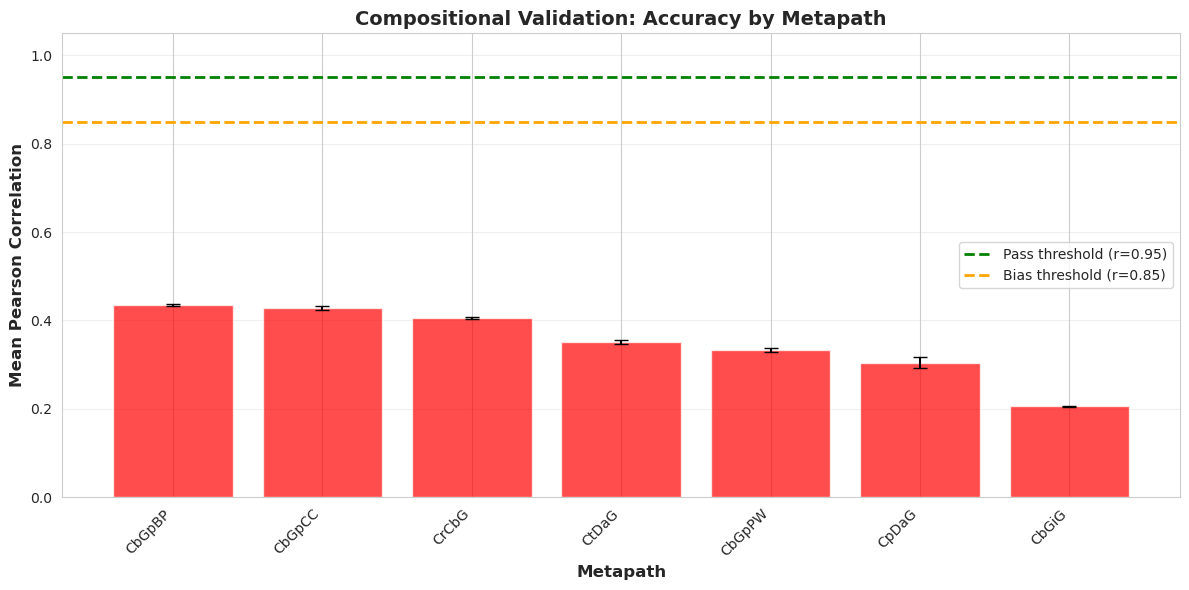

Saved: /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability/results/compositional_validation/plots/correlation_by_metapath.png


In [12]:
# Plot 1: Correlation by metapath
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(summary_df))
colors = ['green' if d == 'PASS' else 'orange' if d == 'BIAS' else 'red' 
          for d in summary_df['decision']]

bars = ax.bar(x, summary_df['mean_pearson_r'], yerr=summary_df['std_pearson_r'],
               color=colors, alpha=0.7, capsize=5)

ax.axhline(0.95, color='green', linestyle='--', linewidth=2, label='Pass threshold (r=0.95)')
ax.axhline(0.85, color='orange', linestyle='--', linewidth=2, label='Bias threshold (r=0.85)')

ax.set_xlabel('Metapath', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Pearson Correlation', fontsize=12, fontweight='bold')
ax.set_title('Compositional Validation: Accuracy by Metapath', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(summary_df['metapath'], rotation=45, ha='right')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'plots' / 'correlation_by_metapath.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {results_dir / 'plots' / 'correlation_by_metapath.png'}")

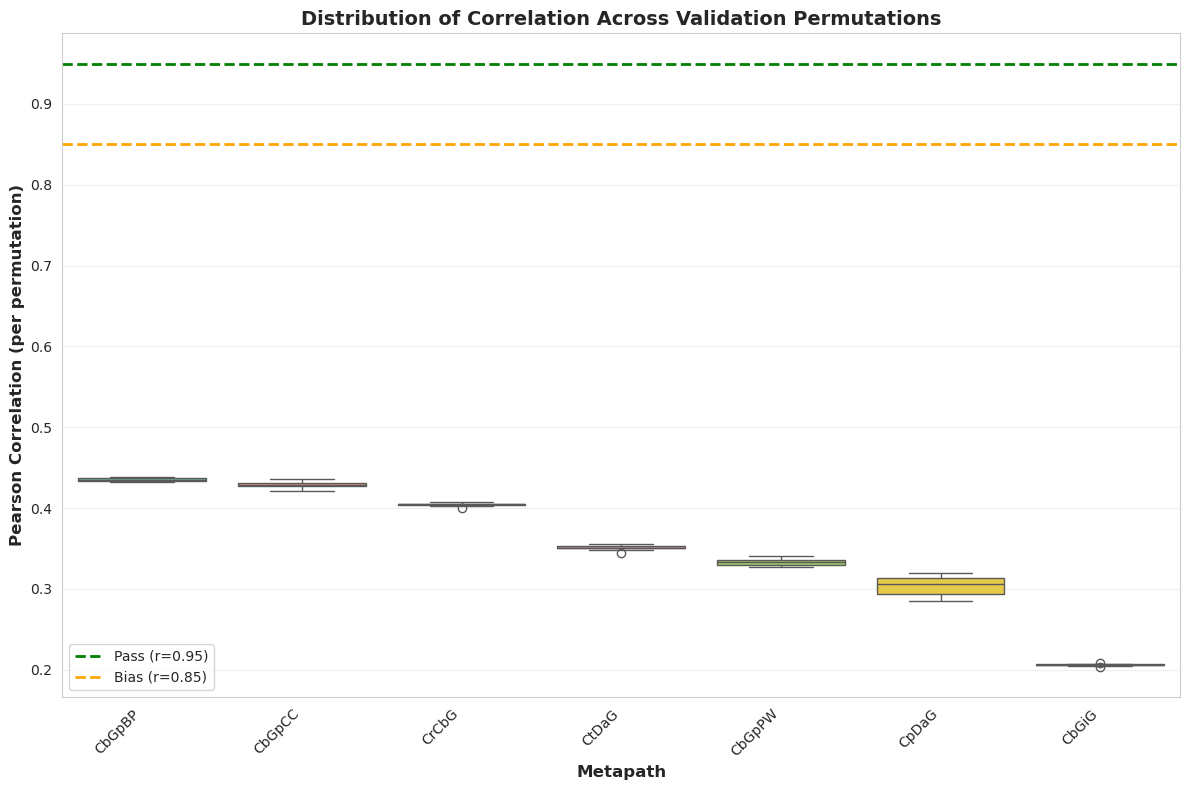

Saved: /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability/results/compositional_validation/plots/correlation_distribution.png


In [13]:
# Plot 2: Correlation distribution across validation permutations
fig, ax = plt.subplots(figsize=(12, 8))

# Collect all per-perm results
all_per_perm = []
for result in all_results:
    df = result['per_perm_results'].copy()
    all_per_perm.append(df)

combined_df = pd.concat(all_per_perm, ignore_index=True)

# Box plot
metapath_order = summary_df['metapath'].tolist()
sns.boxplot(data=combined_df, x='metapath', y='pearson_r', 
            order=metapath_order, ax=ax, palette='Set2')

ax.axhline(0.95, color='green', linestyle='--', linewidth=2, label='Pass (r=0.95)')
ax.axhline(0.85, color='orange', linestyle='--', linewidth=2, label='Bias (r=0.85)')

ax.set_xlabel('Metapath', fontsize=12, fontweight='bold')
ax.set_ylabel('Pearson Correlation (per permutation)', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Correlation Across Validation Permutations', 
             fontsize=14, fontweight='bold')
ax.set_xticklabels(metapath_order, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'plots' / 'correlation_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {results_dir / 'plots' / 'correlation_distribution.png'}")

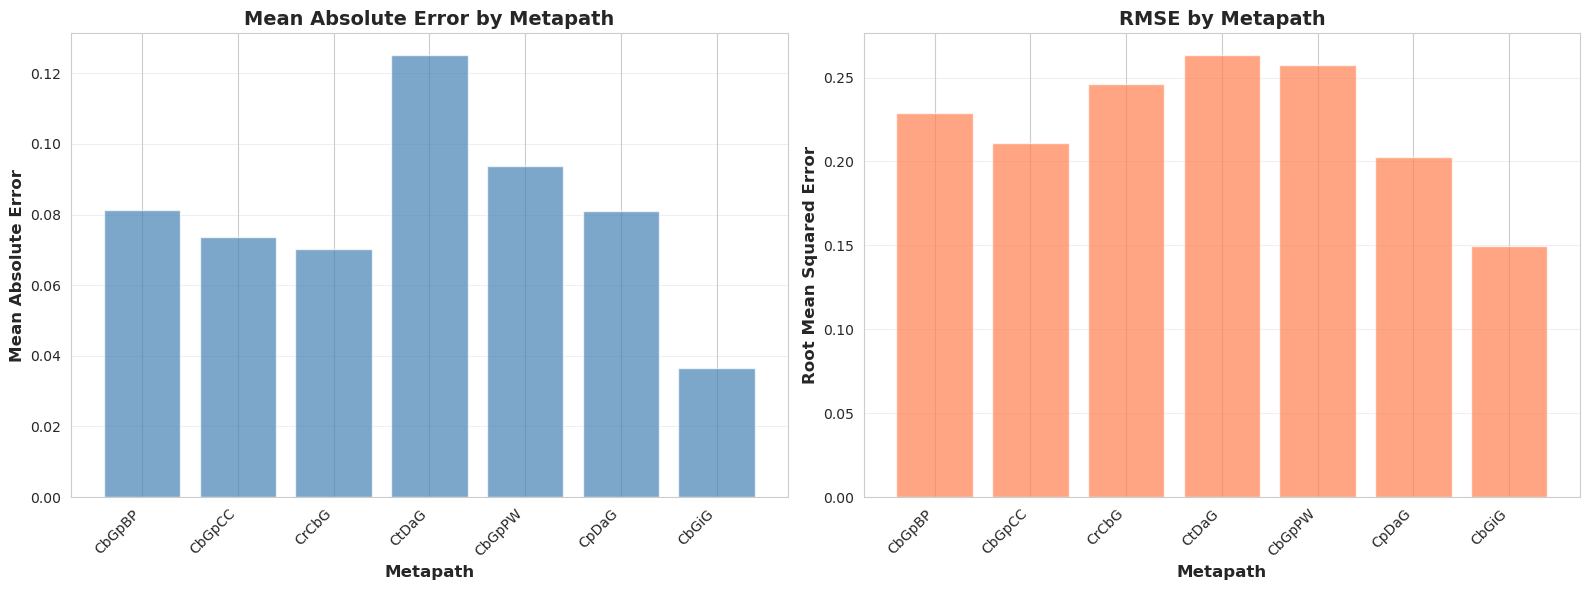

Saved: /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability/results/compositional_validation/plots/error_metrics.png


In [14]:
# Plot 3: MAE and RMSE comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(summary_df))

# MAE
ax1.bar(x, summary_df['mean_mae'], color='steelblue', alpha=0.7)
ax1.set_xlabel('Metapath', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Absolute Error', fontsize=12, fontweight='bold')
ax1.set_title('Mean Absolute Error by Metapath', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(summary_df['metapath'], rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# RMSE
ax2.bar(x, summary_df['mean_rmse'], color='coral', alpha=0.7)
ax2.set_xlabel('Metapath', fontsize=12, fontweight='bold')
ax2.set_ylabel('Root Mean Squared Error', fontsize=12, fontweight='bold')
ax2.set_title('RMSE by Metapath', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(summary_df['metapath'], rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'plots' / 'error_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {results_dir / 'plots' / 'error_metrics.png'}")

## Conclusion

In [15]:
print("\n" + "="*100)
print("COMPOSITIONAL VALIDATION COMPLETE")
print("="*100)

print(f"\nTested: {len(all_results)} 2-hop metapaths")
print(f"Training set: Permutations {train_perms_start}-{train_perms_end}")
print(f"Validation set: Permutations {valid_perms_start}-{valid_perms_end}")

print(f"\nOverall mean Pearson r: {overall_mean_r:.4f}")
print(f"Decision: {overall_decision}")

print(f"\nResults saved to:")
print(f"  - {results_dir / 'accuracy_by_metapath.csv'}")
print(f"  - {results_dir / 'validation_summary.json'}")
print(f"  - {results_dir / 'plots' / '*.png'}")

if overall_decision == 'VALIDATED':
    print(f"\n{'✓'*50}")
    print(f"NEXT STEP: Run notebook 18_null_approximation_comparison.ipynb")
    print(f"{'✓'*50}")
elif overall_decision == 'BIAS_DETECTED':
    print(f"\n{'→'*50}")
    print(f"NEXT STEP: Proceed to notebook 18 with caution (consider bias correction)")
    print(f"{'→'*50}")
else:
    print(f"\n{'✗'*50}")
    print(f"WARNING: Compositional methods not suitable for this dataset")
    print(f"Alternative: Use direct empirical pathway counts (notebooks 15-16)")
    print(f"{'✗'*50}")

print(f"\n{'='*100}\n")


COMPOSITIONAL VALIDATION COMPLETE

Tested: 7 2-hop metapaths
Training set: Permutations 1-20
Validation set: Permutations 21-30

Overall mean Pearson r: 0.3518
Decision: FAILED

Results saved to:
  - /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability/results/compositional_validation/accuracy_by_metapath.csv
  - /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability/results/compositional_validation/validation_summary.json
  - /projects/lgillenwater@xsede.org/repositories/Context-Aware-Path-Probability/results/compositional_validation/plots/*.png

✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗
Alternative: Use direct empirical pathway counts (notebooks 15-16)
✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗✗


